# Day 1 — micrograd
My autograd engine, from memory. Video first, then close it.

In [660]:
import math
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph
import torch
import random
%matplotlib inline

In [661]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [662]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):

        self.label = label
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None

    def __repr__(self):
        return f"data={self.data}"

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __add__(self, other):

        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # print(f'    Calling _backward() (+) on {self}')
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):

        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            # print(f'    Calling _backward() (*) on {self}')
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):

        assert isinstance(other, (int, float)), "Called __pow__ with non-int/float argument!"

        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            # power rule combined with chain rule
            self.grad += other * self.data**(other - 1) * out.grad

        out._backward = _backward

        return out

    def __truediv__(self, other):
        return self * other**-1

    def tanh(self):

        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def relu(self):
        t = max(0, self.data)
        out = Value(t, (self, ), 'relu')

        def _backward():
            if t == 0:
                self.grad += out.grad * 0
            else:
                self.grad += out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad # d/dx(e^x) = e^x

        out._backward = _backward

        return out

    def backward(self):

        def topological_sort(v):

            ordering = []
            visited = set()

            def grow_topological(v):
                if v not in visited:
                    visited.add(v)
                    for child in v._prev:
                        grow_topological(child)
                    ordering.append(v)

            grow_topological(v)

            return ordering

        self.grad = 1.0

        topo = topological_sort(self)

        for v in reversed(topo):
            # print(f'Calling _backward() on {v}')
            v._backward()

In [663]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label= 'f')
L = d*f; L.label = 'L'
L

data=-8.0

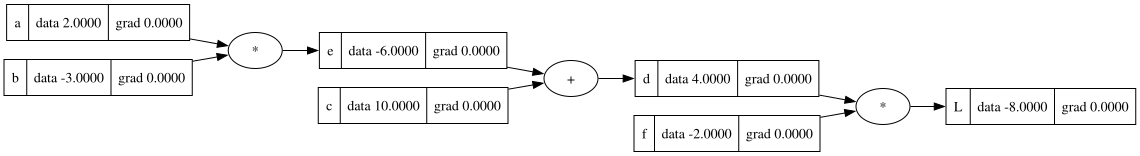

In [664]:
draw_dot(L)

Manual backpropagation

We know, derivate formula: (f(x+h) - f(x))/(h) 

dL/dL = 1

In [665]:
L.grad = 1

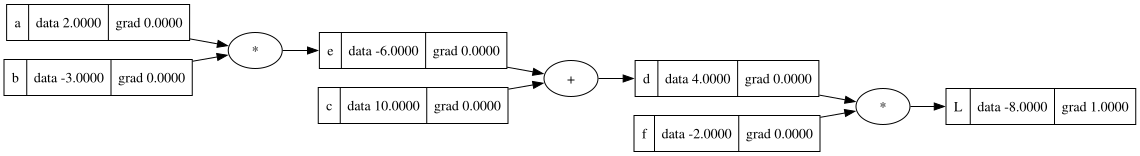

In [666]:
draw_dot(L)

What is the derivative of L with respect to d?

dL/dd = ?
L = d * f
dL/dd = f = -2

dL/df = ?
L = d * f
dL/df = d = 4

In [667]:
d.grad = -2
f.grad = 4

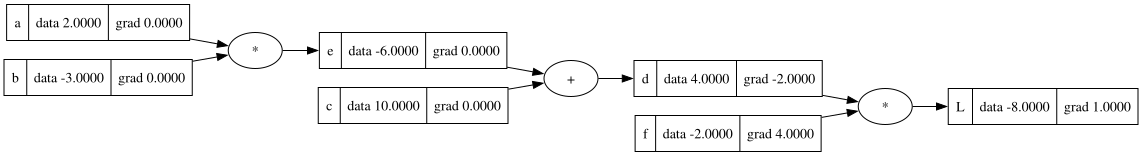

In [668]:
draw_dot(L)

What is the derivative of L with respect to c?

Using chain rule...

dL/dc = dL/dd * dd/dc

From what we know previously, 
dL/dd = -2
dd/dc = If you nudge c with a tiny number, how much will d move = ?

d = c + e
dd/dc = (d(c+h) - d(c))/h
= (c + e + h - c - e)/h = 1.0 = dd/dc

dL/dc = -2.0


dL/de = dL/dd * dd/de
dd/de = Nudge e with tiny num h, how much will d chnage = ?

d = c + e
= (d(e+h)-d(e))/h
= (c+e+h - c - e)/h = 1

dL/de = -2.0

In [669]:
e.grad = -2
c.grad = -2

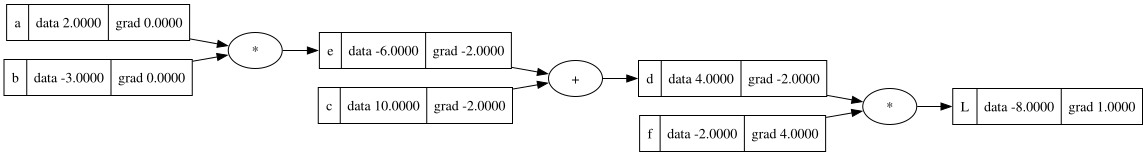

In [670]:
draw_dot(L)

e = a * b

de/db = d(ab)/db = a = 2

dL/db = dL/de * de/db
= -2 * 2
= -4

de/da = b

dL/da = dL/de * de/da
= -2 * -3
= 6

In [671]:
b.grad = -4
a.grad = 6

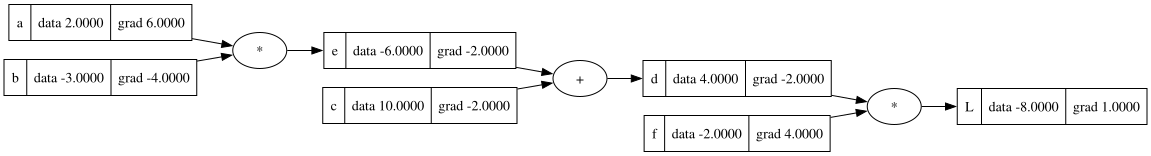

In [672]:
draw_dot(L)

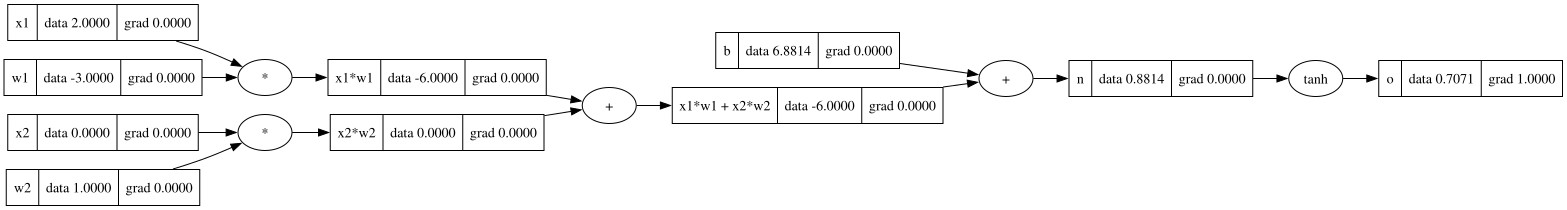

In [673]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.grad = 1
draw_dot(o)

Manual backpropagation of this example

o = tanh(n)

do/dn = d(tanh(n))/dn
= 1 - (tanh(n))**2
= 1 - o**2
= 1 - 0.7071
= 0.5

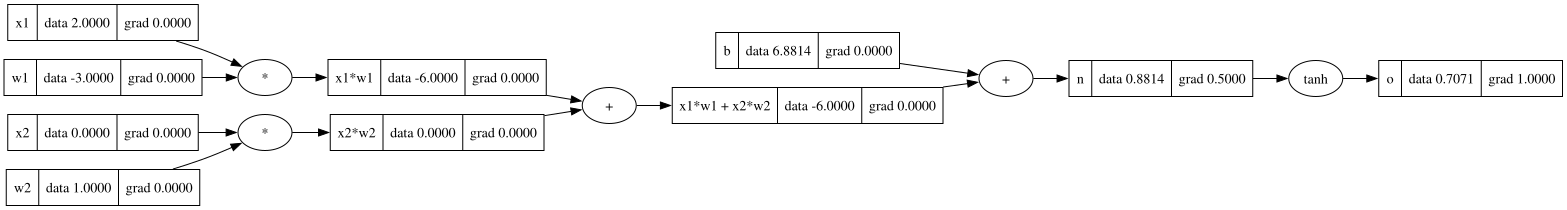

In [674]:
n.grad = 0.5
draw_dot(o)

x1w1+x2w2 = n + b

dn/db = (d(n+h)-d(n))/h
= ((x1w1+x2w2+h+b)-(x1w1+x2w2+b))/h
= 1


do/db = do/dn * dn/db = do/d(x1w1+x2w2)
= 0.5 * 1 
= 0.5

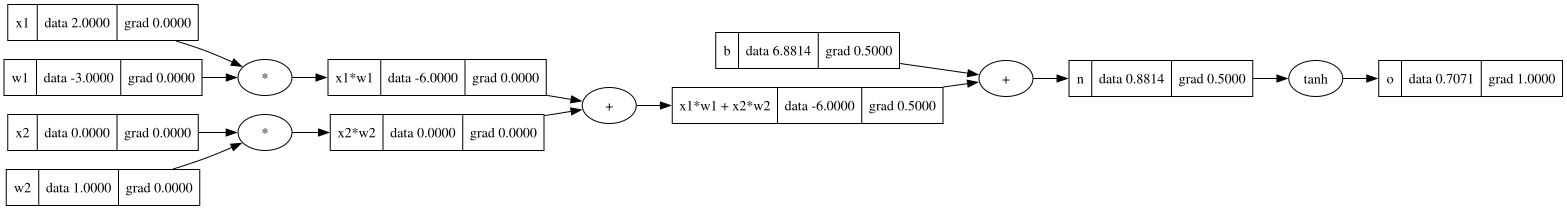

In [675]:
x1w1x2w2.grad = 0.5
b.grad = 0.5
draw_dot(o)

x2w2 + x1w1 = x1w1x2w2

dx1w1x2w2/dx2w2 = dx1w1x2w2/dx1w1 = (d(x1w1+h) - d(x1w1))/h
= (x1w1 + x2w2 + h - (x1w1 + x2w2))/h
= 1.0

do/dx1w1 = do/dx1w1x2w2 * dx1w1x2w2/dx1w1
= 0.5 * 1
= 0.5

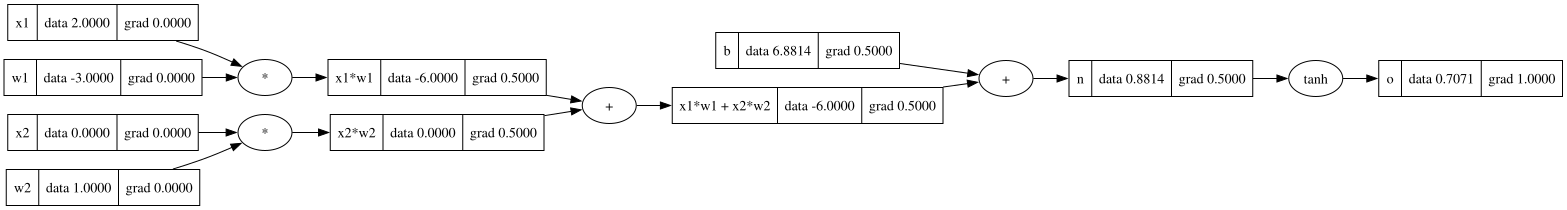

In [676]:
x2w2.grad = 0.5
x1w1.grad = 0.5
draw_dot(o)


x2w2 = x2 * w2
dx2w2/dx2 = w2

x2w2 = x2 * w2
dx2w2/dw2 = x2

do/dw2 = do/dx2w2 * dx2w2/dw2 = 0.5 * 0 = 0
do/dx2 = do/dx2w2 * dx2w2/dx2 = 0.5 * 1 = 0.5

x1w1 = x1 * w1
dx1w1/dx1 = w1

x1w1 = x1 * w1
dx1w1/dw1 = x1

do/dw1 = do/dx1w1 * dx1w1/dw1 = 0.5 * 2 = 1
do/dx1 = do/dx1w1 * dx1w1/dx1 = 0.5 * -3 = -1.5

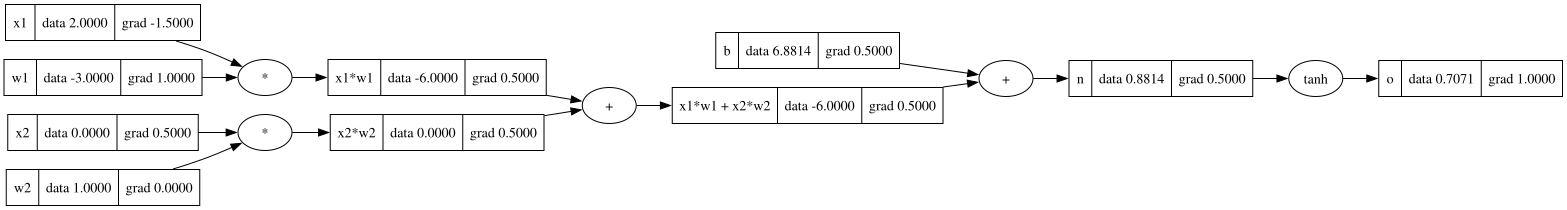

In [677]:
w2.grad = 0
x2.grad = 0.5
w1.grad = 1
x1.grad = -1.5
draw_dot(o)

In [678]:
def incode_bp():
    # inputs x1, x2
    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')

    # weights w1, w2
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')

    # bias of the neuron
    b = Value(6.8813735870195432, label='b')

    # x1*w1 + x2*w2 + b
    x1w1 = x1 * w1; x1w1.label = 'x1*w1'
    x2w2 = x2 * w2; x2w2.label = 'x2*w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
    n = x1w1x2w2 + b; n.label = 'n'
    o = n.tanh(); o.label = 'o'
    o.backward()
    return draw_dot(o)

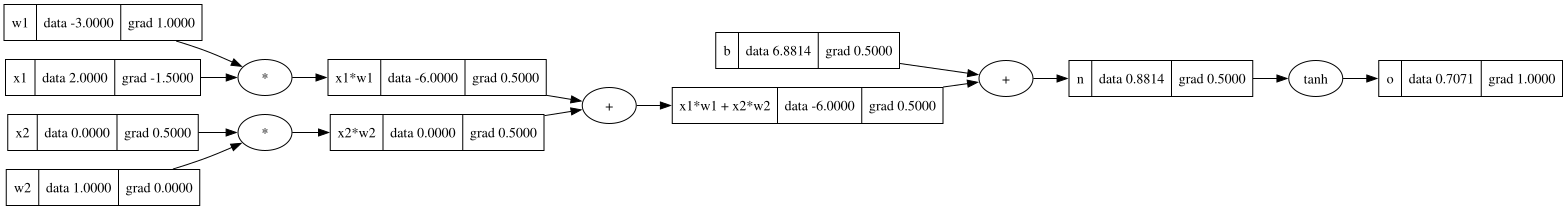

In [679]:
incode_bp()

In [680]:
# the a + a test: same Value used twice — gradients from both paths must ADD
# predict: b = a + a moves 2h when a moves h, so a.grad should be 2
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
print("a.grad after one backward:", a.grad)   # expect 2.0 (with = instead of += this was 1.0)

# the tradeoff += bought: nothing zeroes grads between calls
b.backward()
print("a.grad after second backward:", a.grad)  # accumulates!

a.grad after one backward: 2.0
a.grad after second backward: 4.0


# Day 2 — MLP + training loop (video 2:05 → end)

Boilerplate below (dataset constants + PyTorch verifier) is pasted — same cells Karpathy pastes.
MY exercise: Neuron/Layer/MLP classes + the training loop. Those cells are empty on purpose.

In [681]:
# BOILERPLATE (verifier, from the lecture): same neuron in PyTorch — my engine's gradients must match
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())   # expect 0.5
print('w2', w2.grad.item())   # expect 0.0
print('x1', x1.grad.item())   # expect -1.5
print('w1', w1.grad.item())   # expect 1.0

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## EXERCISE — from memory: Neuron(nin), Layer(nin, nout), MLP(nin, nouts)

Each needs `__call__` (the forward) and a way to hand back all its parameters for the training loop. "It's just layers of this."

In [682]:
class Neuron:
    def __init__(self, nin, is_last_neuron=False) -> None:
        # Generate random weights size of number of inputs
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        # Generate a bias randomly
        self.b = Value(random.uniform(-1,1))
        self.is_last_neuron = is_last_neuron

    def __call__(self, x):
        # w * x + b
        out = sum(wi * xi for wi, xi in zip(self.w, x)) +  self.b
        if self.is_last_neuron == True:
            out = out.tanh() 
        else:
            out = out.relu()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout, is_last_layer=False) -> None:
        self.neurons = [Neuron(nin, is_last_layer) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], i == len(nouts) - 1) for i in range(len(nouts))]
    
    def __call__(self, x) -> Any:
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [683]:
# BOILERPLATE (constants, from the lecture): tiny dataset — 4 samples, 4 targets
x = [2.0, 3.0, -1.0]          # single test input: n = MLP(3, [4, 4, 1]); n(x)

n = MLP(3, [4, 4, 1])

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]   # desired targets

## EXERCISE — from memory: the training loop

Each iteration: forward (predictions + squared-error loss) → zero all grads → backward → update every parameter against its gradient. Print k, loss.data — the number must fall. I already know why the zeroing line exists (2.0 → 4.0).

In [684]:
ypred = [n(row) for row in xs]
ypred

[data=-0.7132918041823445,
 data=-0.7628344797103495,
 data=-0.8818264620593245,
 data=-0.7252505379745695]

In [685]:
loss = 0
for x,y in zip(ypred, ys):
    loss += (x - y)**2
loss

data=5.982070694143612

In [686]:
for i in n.parameters():
    i.grad = 0.0

In [687]:
loss.backward()

In [688]:
for i in n.parameters():
    print(i.grad)

-0.012916522243677205
-0.02583304448735441
-0.02583304448735441
-0.02583304448735441
-1.7870552302213802
-1.8908212616546485
0.9545003741169693
-1.0808031427926454
0.0
0.0
0.0
0.0
1.0586047649470418
1.4148317786456106
-0.702377751248473
0.702377751248473
-0.017625870734557073
4.350432712373349
0.0
2.8001165144345057
1.704048031211474
0.0
-1.6676786366467982
0.0
-1.0676463583137084
-0.6608615584009876
0.0
0.0
0.0
0.0
0.0
0.0
0.11869933637986003
0.0
0.0
0.17175167354334125
-2.0341534913553305
-5.987559845580143
0.0
0.02223984045271715
-3.0678969567578633


In [689]:
step = 0.05

for i in range(40):
    ypred = [n(x) for x in xs]
    loss = sum((x - y)**2 for x,y in zip(ypred, ys))

    for p in n.parameters():
        p.grad = 0

    loss.backward()
    
    # nudge params
    for p in n.parameters():
        p.data+= - step * p.grad
    
    print("Loss", loss)


Loss data=5.982070694143612
Loss data=1.4572240097308087
Loss data=0.5752685536568455
Loss data=0.4290835331427873
Loss data=0.2329487351511383
Loss data=0.17469938027624082
Loss data=0.14163609316260806
Loss data=0.11909016679433881
Loss data=0.10251407782055662
Loss data=0.08977160602494179
Loss data=0.07966689169038679
Loss data=0.07146279091259895
Loss data=0.06467562041307237
Loss data=0.05897338230545642
Loss data=0.05412013835035019
Loss data=0.04994345475813473
Loss data=0.04631434375506561
Loss data=0.04313439266603521
Loss data=0.04032722588784456
Loss data=0.03783268067995564
Loss data=0.0356074772776773
Loss data=0.033717326930764006
Loss data=0.03200034244181351
Loss data=0.030434397844519366
Loss data=0.029000948563935924
Loss data=0.02768433620883677
Loss data=0.02647124962613525
Loss data=0.025350302518567038
Loss data=0.024311699128238388
Loss data=0.023346967226117097
Loss data=0.02244874308285672
Loss data=0.02161059697227251
Loss data=0.0208268905604358
Loss data=0.

In [690]:
# Numerically verifying relu...
a = Value(10).relu()
b = Value(-8).relu()
a.backward()
b.backward()

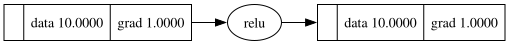

In [691]:
draw_dot(a)

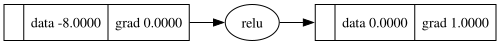

In [692]:
draw_dot(b)